In [4]:
pip install "datasets<4.0.0"

In [5]:
from datasets import load_dataset

# Load the restaurant subset
dataset = load_dataset("alexcadillon/SemEval2014Task4", "restaurants")

# Explore
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


SemEval2014Task4.py: 0.00B [00:00, ?B/s]

restaurants/trial/0000.parquet:   0%|          | 0.00/11.5k [00:00<?, ?B/s]

restaurants/train/0000.parquet:   0%|          | 0.00/233k [00:00<?, ?B/s]

restaurants/test/0000.parquet:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Generating trial split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/3041 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/800 [00:00<?, ? examples/s]

DatasetDict({
    trial: Dataset({
        features: ['sentenceId', 'text', 'aspectTerms', 'aspectCategories'],
        num_rows: 100
    })
    train: Dataset({
        features: ['sentenceId', 'text', 'aspectTerms', 'aspectCategories'],
        num_rows: 3041
    })
    test: Dataset({
        features: ['sentenceId', 'text', 'aspectTerms', 'aspectCategories'],
        num_rows: 800
    })
})


In [6]:
dataset['train'][:2]

{'sentenceId': ['3121', '2777'],
 'text': ['But the staff was so horrible to us.',
  "To be completely fair, the only redeeming factor was the food, which was above average, but couldn't make up for all the other deficiencies of Teodora."],
 'aspectTerms': [[{'term': 'staff',
    'polarity': 'negative',
    'from': '8',
    'to': '13'}],
  [{'term': 'food', 'polarity': 'positive', 'from': '57', 'to': '61'}]],
 'aspectCategories': [[{'category': 'service', 'polarity': 'negative'}],
  [{'category': 'food', 'polarity': 'positive'},
   {'category': 'anecdotes/miscellaneous', 'polarity': 'negative'}]]}

In [7]:
# all different category available values
list({dic['category'] for sample in dataset['train']['aspectCategories'] for dic in sample})

['ambience', 'anecdotes/miscellaneous', 'price', 'food', 'service']

In [8]:
# all different aspect_term available values
len(list({dic['term'] for sample in dataset['train']['aspectTerms'] for dic in sample}))

1288

We see that the number of terms is very large and training a model working with aspect_terms can be difficult so we train the model on aspect_categories.

In [9]:
type(dataset['train'])

datasets.arrow_dataset.Dataset

In [10]:
import pandas as pd

def extract_sentence_category(df):
    rows = []

    for _, row in df.iterrows():
        sentence = row['text']
        categories = row['aspectCategories']

        if categories:  # skip empty ones
            for cat in categories:
                rows.append({
                    'sentence': sentence,
                    'category': cat['category'],
                    'polarity': cat['polarity']
                })

    return pd.DataFrame(rows)

In [11]:
train_df = pd.DataFrame(dataset['train'])
test_df  = pd.DataFrame(dataset['test'])

flat_train_df = extract_sentence_category(train_df)
flat_test_df  = extract_sentence_category(test_df)

print("Train size:", flat_train_df.shape)
print("Test size:", flat_test_df.shape)

flat_train_df.head()

Train size: (3713, 3)
Test size: (1025, 3)


,sentence,category,polarity
0,But the staff was so horrible to us.,service,negative
1,"To be completely fair, the only redeeming fact...",food,positive
2,"To be completely fair, the only redeeming fact...",anecdotes/miscellaneous,negative
3,"The food is uniformly exceptional, with a very...",food,positive
4,Where Gabriela personaly greets you and recomm...,service,positive


In [12]:
print(flat_train_df['polarity'].unique())
print(flat_train_df[flat_train_df['polarity'] == 'conflict']['category'])
list(flat_train_df[flat_train_df['polarity'] == 'conflict']['sentence'])[:5]

['negative' 'positive' 'conflict' 'neutral']
15                      service
70                         food
95      anecdotes/miscellaneous
102                        food
106                     service
                 ...           
3577    anecdotes/miscellaneous
3579    anecdotes/miscellaneous
3629                    service
3635                   ambience
3654                       food
Name: category, Length: 195, dtype: object


['It took half an hour to get our check, which was perfect since we could sit, have drinks and talk!',
 'The food was delicious but do not come here on a empty stomach.',
 'Go here for a romantic dinner but not for an all out wow dining experience.',
 'The menu is limited but almost all of the dishes are excellent.',
 "The service varys from day to day- sometimes they're very nice, and sometimes not."]

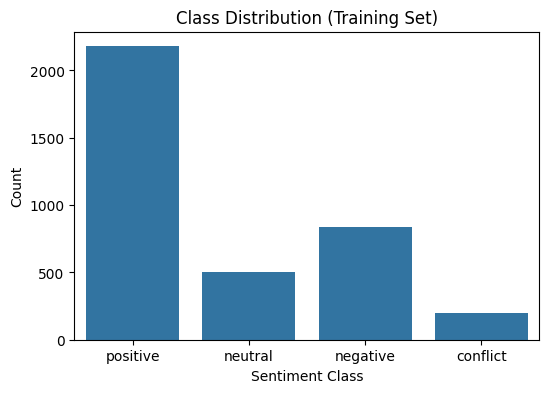

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='polarity', data=flat_train_df, order=['positive','neutral','negative','conflict'])
plt.title("Class Distribution (Training Set)")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.show()

In [18]:
flat_train_df['split'] = 'train'
flat_test_df['split'] = 'test'

combined_df = pd.concat([flat_train_df, flat_test_df])
combined_df.head()

,sentence,category,polarity,split
0,But the staff was so horrible to us.,service,negative,train
1,"To be completely fair, the only redeeming fact...",food,positive,train
2,"To be completely fair, the only redeeming fact...",anecdotes/miscellaneous,negative,train
3,"The food is uniformly exceptional, with a very...",food,positive,train
4,Where Gabriela personaly greets you and recomm...,service,positive,train


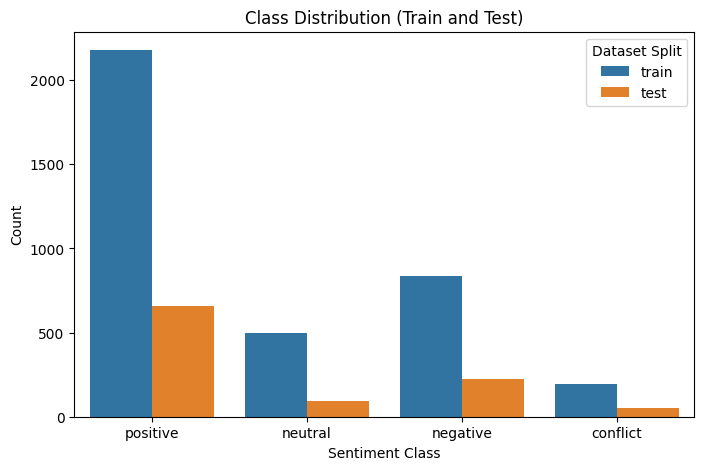

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,5))

sns.countplot(
    data=combined_df,
    x='polarity',
    hue='split',
    order=['positive','neutral','negative','conflict']
)

plt.title("Class Distribution (Train and Test)")
plt.xlabel("Sentiment Class")
plt.ylabel("Count")
plt.legend(title="Dataset Split")
plt.show()

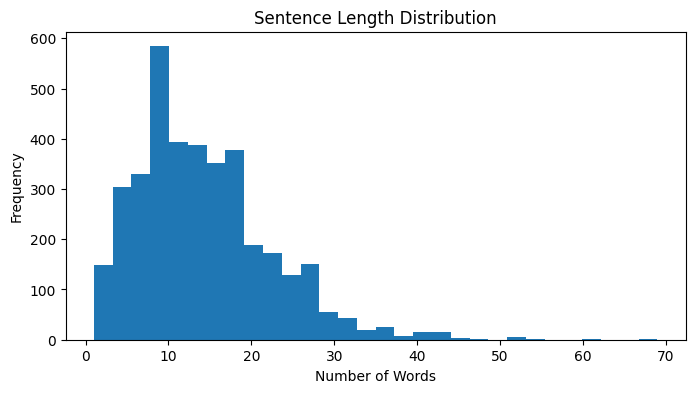

In [20]:
flat_train_df['sentence_length'] = flat_train_df['sentence'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,4))
plt.hist(flat_train_df['sentence_length'], bins=30)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [21]:
!pip install wordcloud

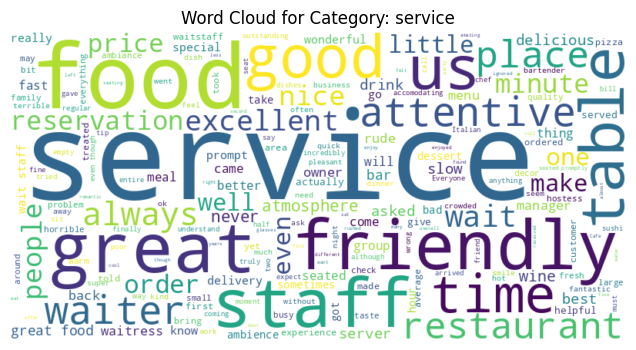

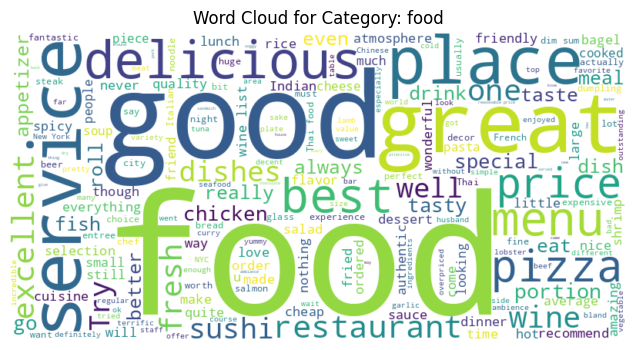

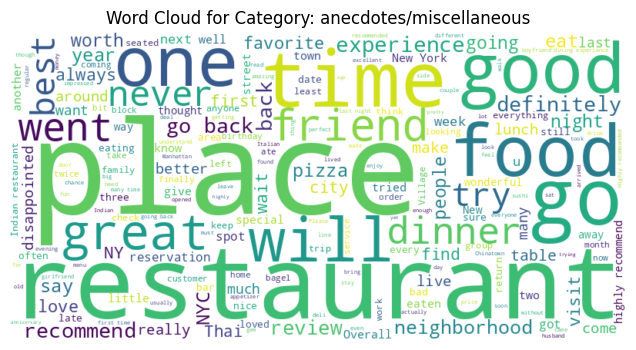

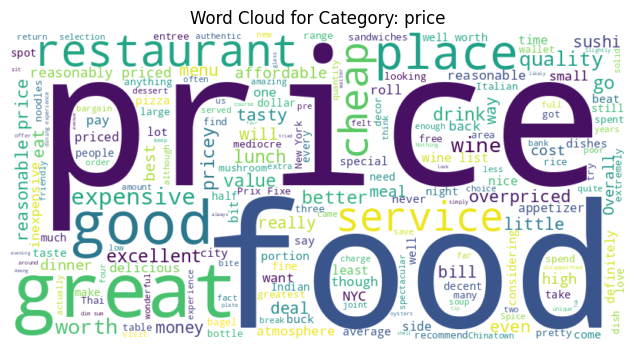

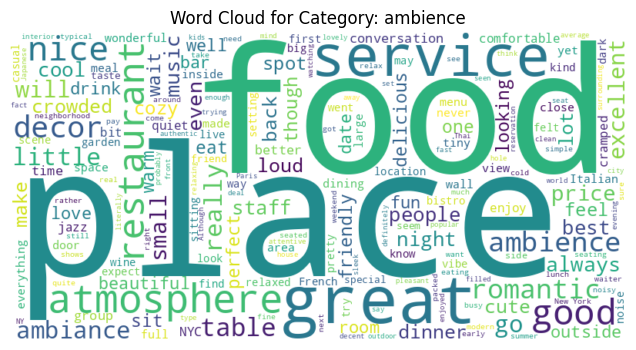

In [22]:
from wordcloud import WordCloud

categories = flat_train_df['category'].unique()

for cat in categories:
    text = " ".join(flat_train_df[flat_train_df['category'] == cat]['sentence'])

    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for Category: {cat}")
    plt.show()